<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/Stage_1_ViT_Train_Loss_Plot_From_Out_Files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving model_20658_0.out to model_20658_0 (1).out
Saving model_20658_1.out to model_20658_1 (1).out
Saving model_20658_2.out to model_20658_2 (1).out
Saving model_20658_3.out to model_20658_3 (1).out


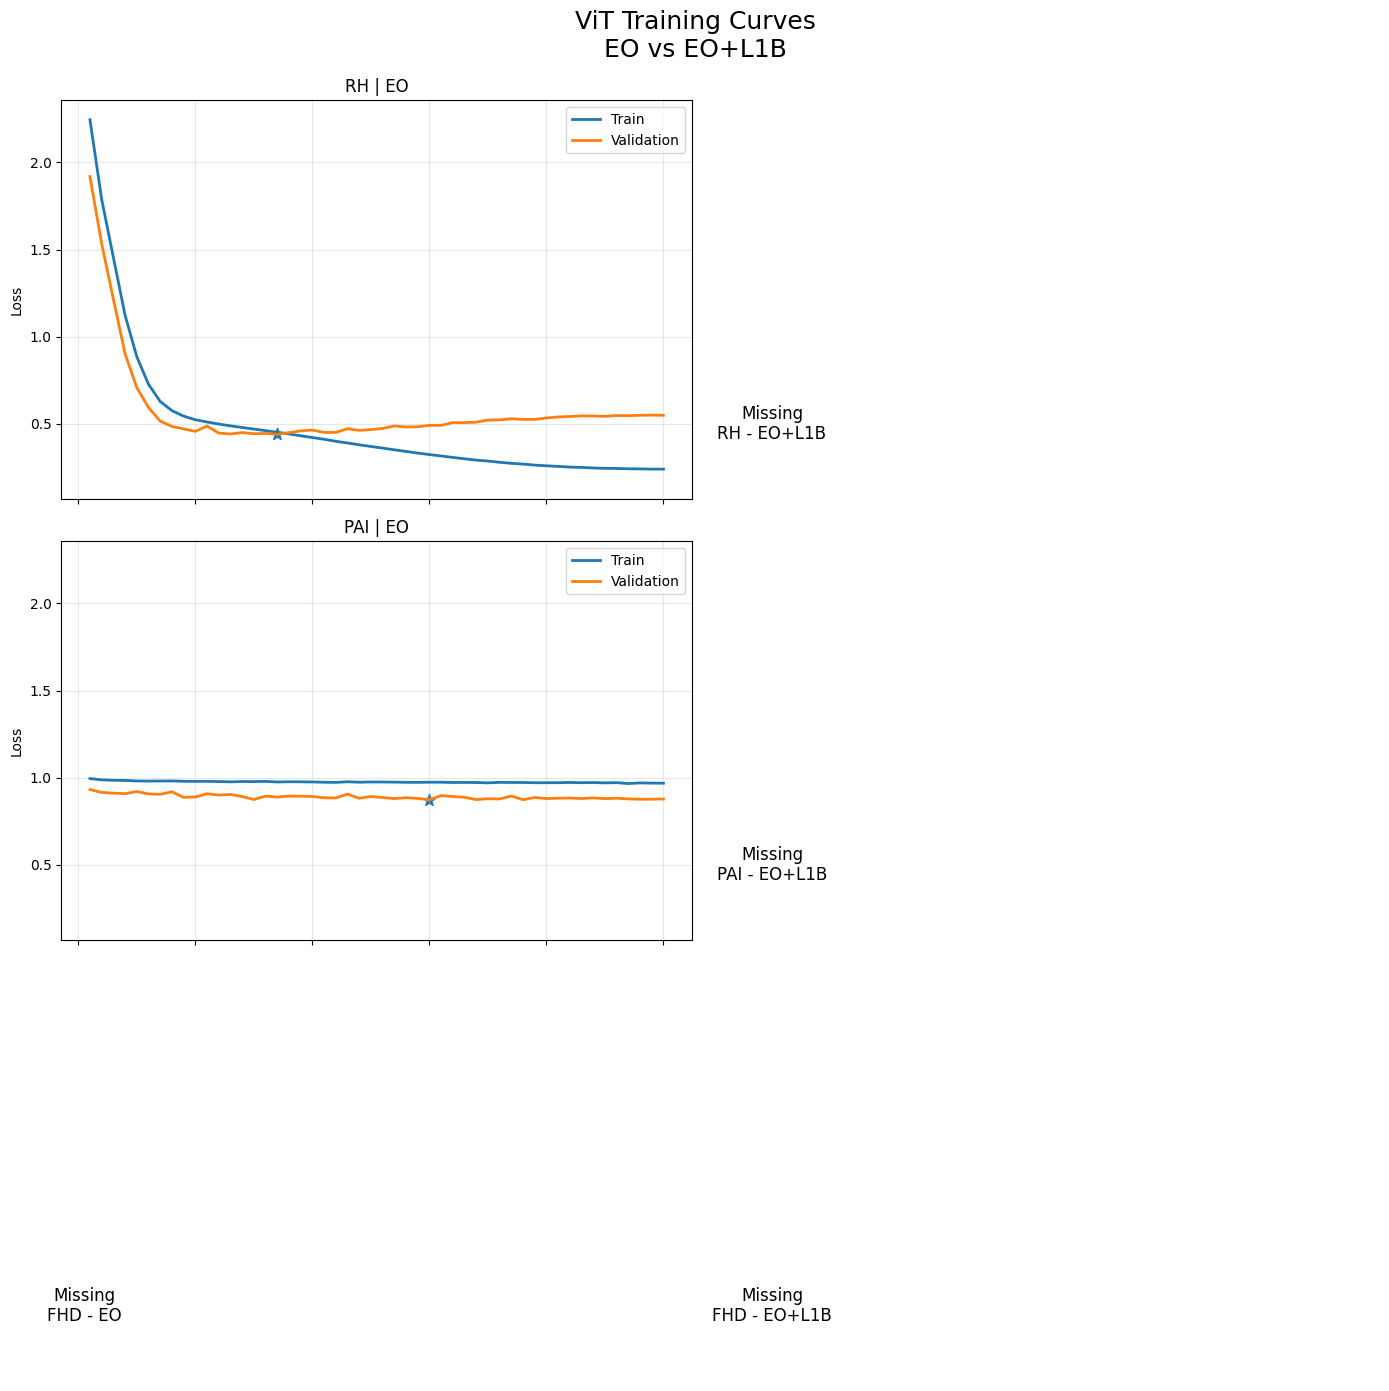

In [2]:
# # ============================================================
# # ViT Training Loss Dashboard (3x2 Panel)
# # Upload all 6 .out files when prompted
# # ============================================================

# import re
# import io
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from google.colab import files

# # ------------------------------------------------------------
# # Upload files
# # ------------------------------------------------------------
# uploaded = files.upload()

# # ------------------------------------------------------------
# # Parse a single .out file
# # ------------------------------------------------------------
# def parse_log(text):

#     # Task
#     task_match = re.search(r"Task:\s*(\w+)", text)
#     task = task_match.group(1) if task_match else "Unknown"

#     # Modality
#     mod_match = re.search(r"Modalities:\s*(.+)", text)
#     modality_raw = mod_match.group(1).strip() if mod_match else "Unknown"

#     if "EO_only" in modality_raw:
#         modality = "EO"
#     elif "+" in modality_raw:
#         modality = "EO_plus_L1B"
#     else:
#         modality = modality_raw

#     epochs = []
#     train_losses = []
#     val_losses = []

#     pattern = (
#         r"Epoch\s+(\d+)\/\d+\s+\|\s+Train:\s+([0-9.]+)"
#         r"\s+\|\s+Val:\s+([0-9.]+)"
#     )

#     for m in re.finditer(pattern, text):
#         epochs.append(int(m.group(1)))
#         train_losses.append(float(m.group(2)))
#         val_losses.append(float(m.group(3)))

#     return {
#         "task": task,
#         "modality": modality,
#         "epochs": np.array(epochs),
#         "train": np.array(train_losses),
#         "val": np.array(val_losses),
#     }

# # ------------------------------------------------------------
# # Read all uploaded files
# # ------------------------------------------------------------
# runs = []

# for fname, content in uploaded.items():

#     try:
#         text = content.decode("utf-8", errors="ignore")
#     except:
#         text = str(content)

#     run = parse_log(text)
#     run["filename"] = fname

#     runs.append(run)

# # ------------------------------------------------------------
# # Determine common y-axis range
# # ------------------------------------------------------------
# all_losses = []

# for r in runs:
#     all_losses.extend(r["train"])
#     all_losses.extend(r["val"])

# ymin = min(all_losses) * 0.95
# ymax = max(all_losses) * 1.05

# # ------------------------------------------------------------
# # Desired panel order
# # ------------------------------------------------------------
# tasks = ["RH", "PAI", "FHD"]
# modalities = ["EO", "EO+L1B"]

# # Build lookup
# lookup = {}

# for r in runs:
#     lookup[(r["task"], r["modality"])] = r

# # ------------------------------------------------------------
# # Plot
# # ------------------------------------------------------------
# fig, axes = plt.subplots(
#     3,
#     2,
#     figsize=(14, 14),
#     sharex=True,
#     sharey=True
# )

# for row, task in enumerate(tasks):
#     for col, modality in enumerate(modalities):

#         ax = axes[row, col]

#         key = (task, modality)

#         if key not in lookup:
#             ax.text(
#                 0.5,
#                 0.5,
#                 f"Missing\n{task} - {modality}",
#                 ha="center",
#                 va="center",
#                 fontsize=12
#             )
#             ax.set_axis_off()
#             continue

#         run = lookup[key]

#         epochs = run["epochs"]
#         train_loss = run["train"]
#         val_loss = run["val"]

#         ax.plot(
#             epochs,
#             train_loss,
#             linewidth=2,
#             label="Train"
#         )

#         ax.plot(
#             epochs,
#             val_loss,
#             linewidth=2,
#             label="Validation"
#         )

#         # Best validation epoch
#         best_idx = np.argmin(val_loss)

#         ax.scatter(
#             epochs[best_idx],
#             val_loss[best_idx],
#             s=80,
#             marker="*"
#         )

#         ax.set_title(f"{task} | {modality}")

#         ax.grid(True, alpha=0.3)

#         ax.set_ylim(ymin, ymax)

#         if row == 2:
#             ax.set_xlabel("Epoch")

#         if col == 0:
#             ax.set_ylabel("Loss")

#         ax.legend()

# # ------------------------------------------------------------
# # Overall formatting
# # ------------------------------------------------------------
# plt.suptitle(
#     "ViT Training Curves\nEO vs EO+L1B",
#     fontsize=18,
#     y=0.99
# )

# plt.tight_layout()
# plt.show()

Saving model_20658_0.out to model_20658_0 (2).out
Saving model_20658_1.out to model_20658_1 (2).out
Saving model_20658_2.out to model_20658_2 (2).out
Saving model_20658_3.out to model_20658_3 (2).out

FILES DETECTED
Task=RH   | Modality=EO      | Epochs=50
Task=RH   | Modality=EO_plus_L1B | Epochs=50
Task=PAI  | Modality=EO      | Epochs=50
Task=PAI  | Modality=EO_plus_L1B | Epochs=50


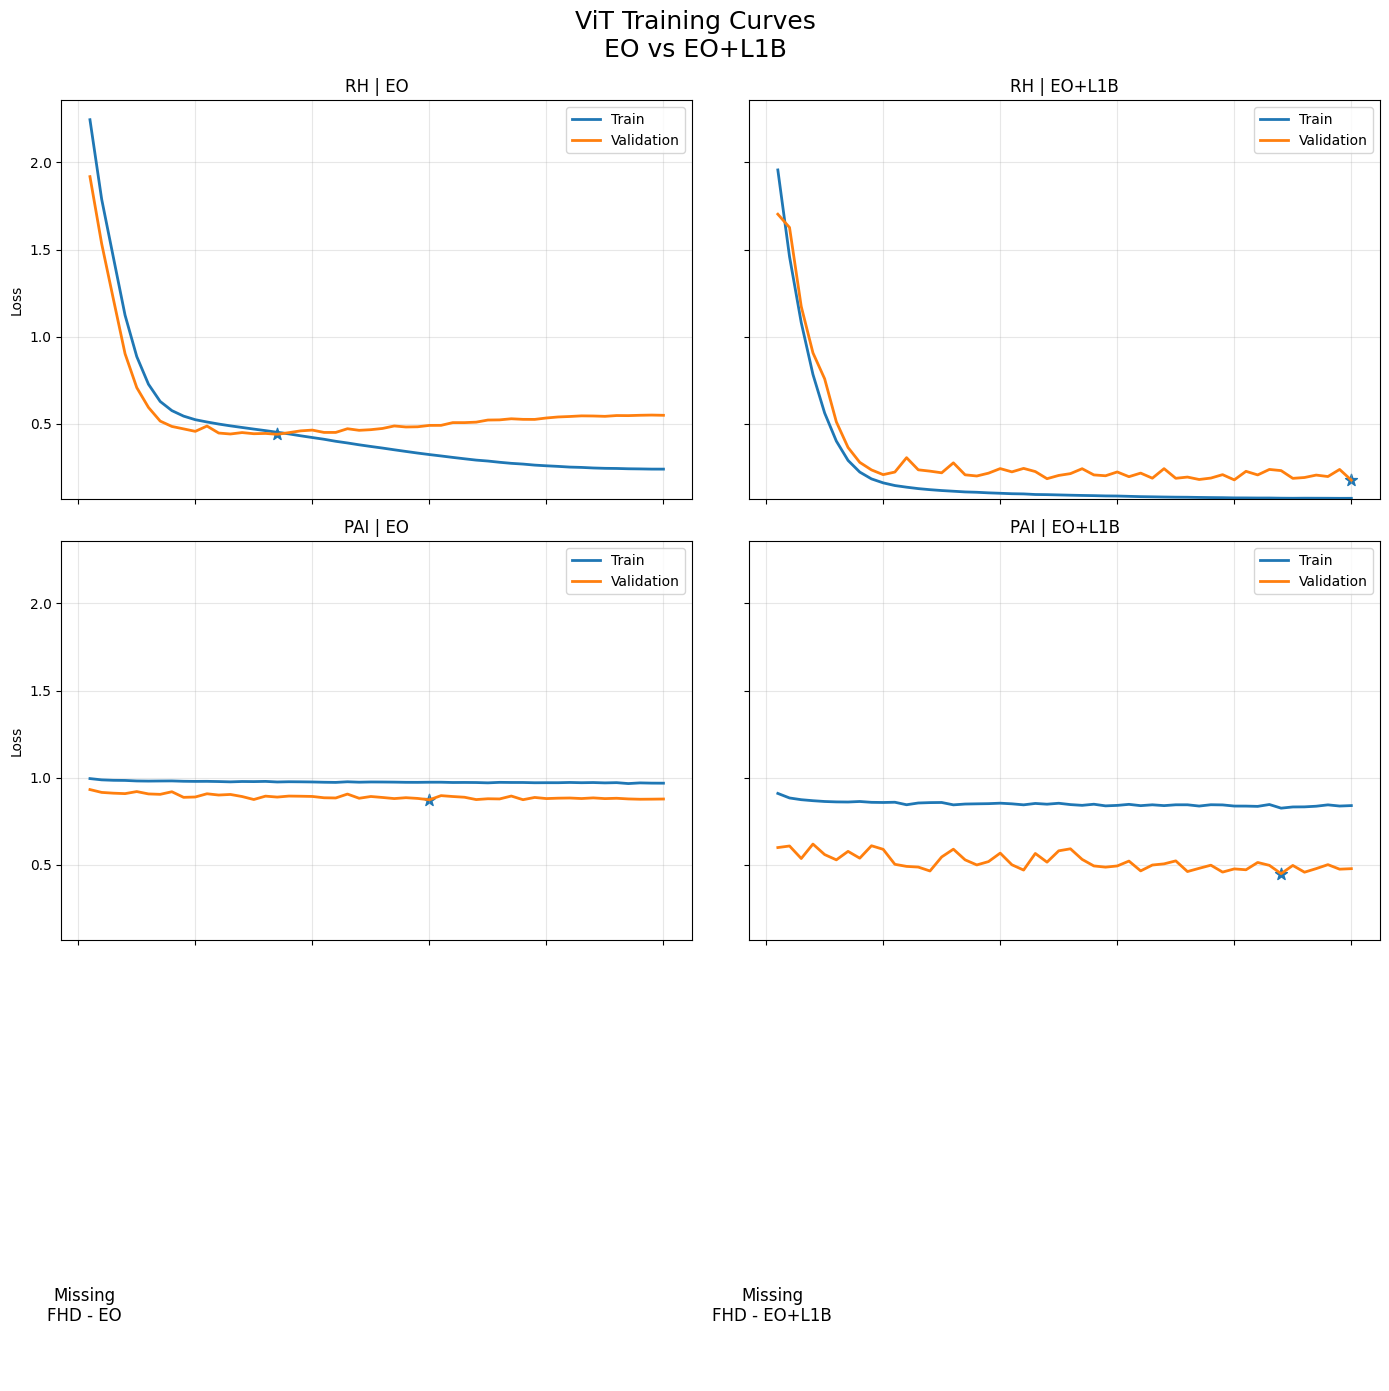

In [3]:
# ============================================================
# ViT Training Loss Dashboard (3x2 Panel)
# Upload all 6 .out files when prompted
# ============================================================

import re
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

# ------------------------------------------------------------
# Upload files
# ------------------------------------------------------------
uploaded = files.upload()

# ------------------------------------------------------------
# Parse a single .out file
# ------------------------------------------------------------
def parse_log(text):
    """
    Parse a Stage 1 Final training .out file
    """

    import re
    import numpy as np

    # --------------------------------------------------
    # Task
    # --------------------------------------------------
    task_match = re.search(r"Task:\s*(\w+)", text)
    task = task_match.group(1).strip() if task_match else "Unknown"

    # --------------------------------------------------
    # Modality
    # --------------------------------------------------
    mod_match = re.search(r"Modalities:\s*(.+)", text)

    if mod_match:
        modality_raw = mod_match.group(1).strip().lower()

        if "eo_only" in modality_raw:
            modality = "EO"

        elif "l1b" in modality_raw:
            modality = "EO+L1B"

        else:
            modality = modality_raw

    else:
        modality = "Unknown"

    # --------------------------------------------------
    # Epoch losses
    # --------------------------------------------------
    epochs = []
    train_losses = []
    val_losses = []

    epoch_pattern = re.compile(
        r"Epoch\s+(\d+)/\d+\s+\|\s+Train:\s+([0-9.]+)\s+\|\s+Val:\s+([0-9.]+)"
    )

    for match in epoch_pattern.finditer(text):
        epochs.append(int(match.group(1)))
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

    return {
        "task": task,
        "modality": modality,
        "epochs": np.array(epochs),
        "train": np.array(train_losses),
        "val": np.array(val_losses),
    }

print("\n========================================")
print("FILES DETECTED")
print("========================================")

for r in runs:
    print(
        f"Task={r['task']:4s} | "
        f"Modality={r['modality']:7s} | "
        f"Epochs={len(r['epochs'])}"
    )

# ------------------------------------------------------------
# Read all uploaded files
# ------------------------------------------------------------
runs = []

for fname, content in uploaded.items():

    try:
        text = content.decode("utf-8", errors="ignore")
    except:
        text = str(content)

    run = parse_log(text)
    run["filename"] = fname

    runs.append(run)

# ------------------------------------------------------------
# Determine common y-axis range
# ------------------------------------------------------------
all_losses = []

for r in runs:
    all_losses.extend(r["train"])
    all_losses.extend(r["val"])

ymin = min(all_losses) * 0.95
ymax = max(all_losses) * 1.05

# ------------------------------------------------------------
# Desired panel order
# ------------------------------------------------------------
tasks = ["RH", "PAI", "FHD"]
modalities = ["EO", "EO+L1B"]

# Build lookup
lookup = {}

for r in runs:
    lookup[(r["task"], r["modality"])] = r

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

for row, task in enumerate(tasks):
    for col, modality in enumerate(modalities):

        ax = axes[row, col]

        key = (task, modality)

        if key not in lookup:
            ax.text(
                0.5,
                0.5,
                f"Missing\n{task} - {modality}",
                ha="center",
                va="center",
                fontsize=12
            )
            ax.set_axis_off()
            continue

        run = lookup[key]

        epochs = run["epochs"]
        train_loss = run["train"]
        val_loss = run["val"]

        ax.plot(
            epochs,
            train_loss,
            linewidth=2,
            label="Train"
        )

        ax.plot(
            epochs,
            val_loss,
            linewidth=2,
            label="Validation"
        )

        # Best validation epoch
        best_idx = np.argmin(val_loss)

        ax.scatter(
            epochs[best_idx],
            val_loss[best_idx],
            s=80,
            marker="*"
        )

        ax.set_title(f"{task} | {modality}")

        ax.grid(True, alpha=0.3)

        ax.set_ylim(ymin, ymax)

        if row == 2:
            ax.set_xlabel("Epoch")

        if col == 0:
            ax.set_ylabel("Loss")

        ax.legend()

# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------
plt.suptitle(
    "ViT Training Curves\nEO vs EO+L1B",
    fontsize=18,
    y=0.99
)

plt.tight_layout()
plt.show()